# Student Performance Prediction Using Machine Learning

## 1. Introduction

Student performance prediction plays a crucial role in identifying
students who may be at academic risk. Early identification enables
educational institutions to implement timely intervention strategies.

This project aims to develop a machine learning classification model
to predict whether a student will pass or fail based on academic,
demographic, and social attributes.

## 2. Data Collection & Description

The dataset used in this study is the Student Performance dataset
obtained from the UCI Machine Learning Repository.

The dataset contains 395 student records and 33 attributes,
including demographic, social, and academic features.
The final grade (G3) is used to determine student performance
and is later transformed into a binary classification target.

## 3. Mounting Google Drive
Google Drive is mounted to access the dataset stored in the project directory.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Data Loading
The student-mat.csv dataset is loaded using pandas.
The dataset uses a semicolon as a delimiter.


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/Student_Performance_Research/dataset/student-mat.csv"
df = pd.read_csv(path, sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 5. Dataset Exploration

In this section, we examine the structure and summary statistics
of the dataset to better understand its attributes.

In [3]:
df.shape


(395, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 6. Target Variable Engineering

To convert the problem into a binary classification task,
the final grade (G3) is transformed into a Pass/Fail variable.
Students scoring 10 or above are labeled as Pass (1),
while those below 10 are labeled as Fail (0).

In [6]:
df['Pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

df['Pass'].value_counts()

,count
Pass,
1,265
0,130


## 7. Feature and Target Separation

The dataset is divided into input features (X) and the target variable (y).
The original final grade (G3) is removed from the feature set to prevent data leakage.

In [7]:
# Separate features and target variable
X = df.drop(['G3', 'Pass'], axis=1)
y = df['Pass']

X.shape, y.shape

((395, 32), (395,))

## 8. Data Preprocessing

In [8]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(395, 41)

## 9. Train-Test Split

The dataset is divided into training and testing sets.
80% of the data is used for training and 20% for evaluation.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((316, 41), (79, 41))

## 10. Logistic Regression Model

Logistic Regression is used as a baseline classification model
to predict whether a student will pass or fail.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train model
lr.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test)

# Evaluate model
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.9240506329113924

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.96      0.92      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.92      0.92        79
weighted avg       0.93      0.92      0.92        79



## 11. Random Forest Model

Random Forest is used to capture nonlinear relationships between features.

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Train model
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Evaluate model
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9240506329113924

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.96      0.90        27
           1       0.98      0.90      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79



## 12. Cross-Validation Analysis

To evaluate model stability and generalization capability,
5-fold stratified cross-validation was performed on the Random Forest model.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation accuracy scores: [0.88607595 0.92405063 0.87341772 0.92405063 0.92405063]
Mean CV Accuracy: 0.9063291139240507
Standard Deviation: 0.022070374397674328


## 13. ROC Curve and AUC Analysis

Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC)
are used to evaluate the classification performance beyond accuracy.

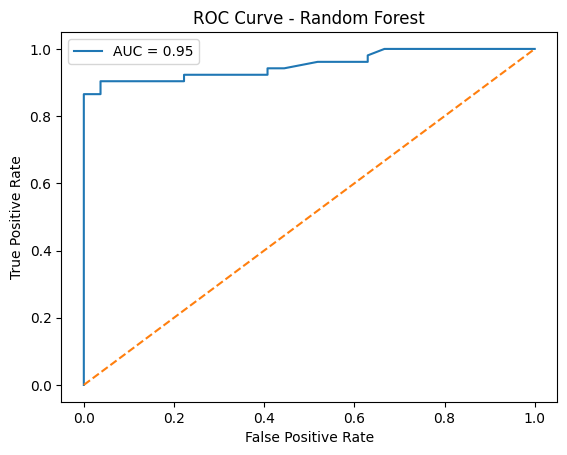

AUC Score: 0.9526353276353277


In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

The Random Forest model achieved an AUC score of 0.95, indicating excellent discriminative capability between students likely to pass and fail. The ROC curve further confirms strong model sensitivity and specificity across classification thresholds.


## 14. Feature Importance Analysis

Feature importance is analyzed using the Random Forest model
to identify the most influential factors affecting student performance.

In [14]:
# Extract feature importance from Random Forest
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 10 most important features
importance_df.head(10)

,Feature,Importance
14,G2,0.353359
13,G1,0.202502
12,absences,0.037287
5,failures,0.031201
0,age,0.026300
8,goout,0.026275
2,Fedu,0.024297
11,health,0.018576
1,Medu,0.018536
10,Walc,0.017333


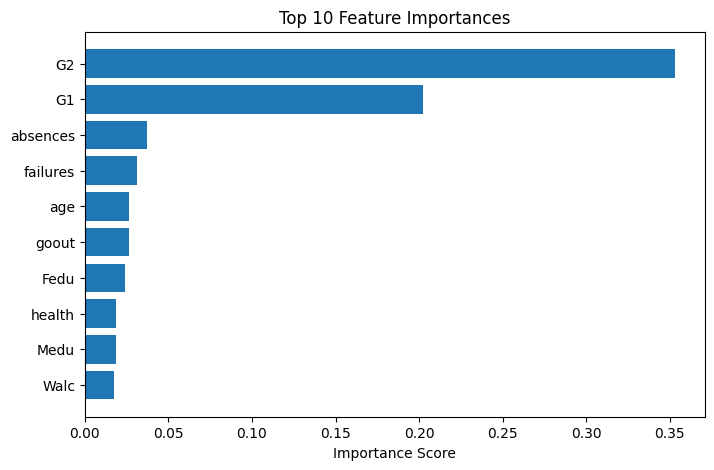

In [15]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importances")
plt.show()

## 15. SHAP Interpretability Analysis

In [16]:
!pip install shap

In [17]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

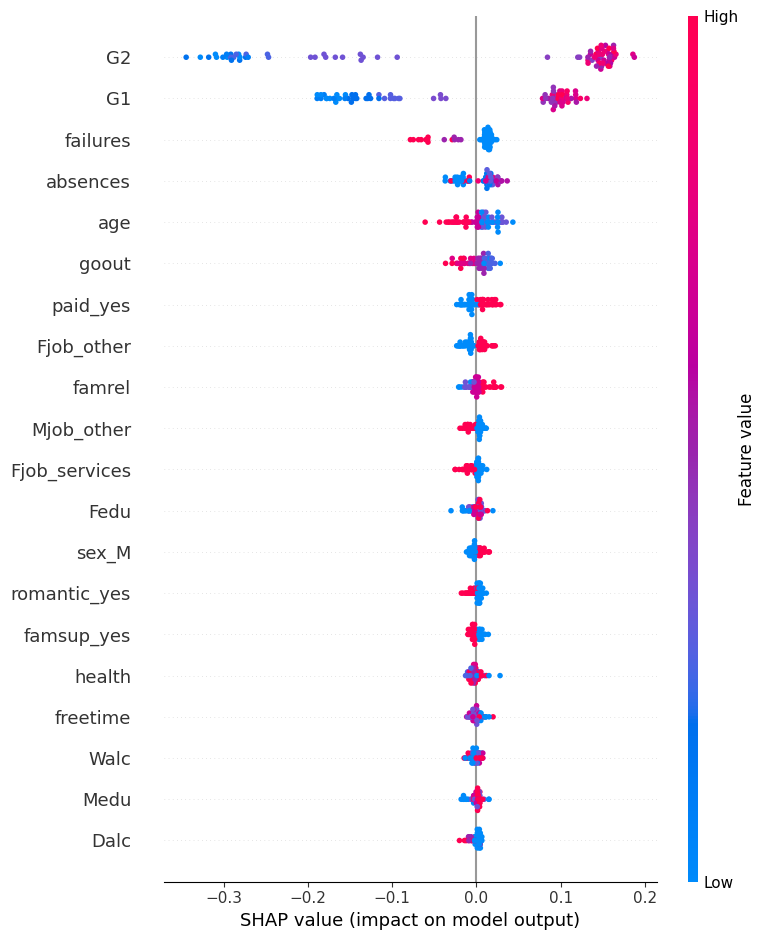

In [18]:
shap.summary_plot(shap_values.values[:, :, 1], X_test)

## 16. Model Comparison and Discussion

Both Logistic Regression and Random Forest achieved a test accuracy of approximately 92.4%. However, evaluation beyond accuracy reveals important distinctions in predictive behavior.

Random Forest demonstrated superior recall for the Fail class (0.96), making it more effective in identifying academically at-risk students. In contrast, Logistic Regression showed slightly higher recall for the Pass class. Since early detection of failing students is the primary objective of this study, minimizing false negatives in the Fail category is critically important.

Furthermore, 5-fold stratified cross-validation yielded a mean accuracy of 90.6% (σ = 0.022), confirming stable generalization performance. The Random Forest model also achieved an AUC score of 0.95, indicating excellent discriminative capability between pass and fail outcomes across classification thresholds.

Considering its strong recall for at-risk students, robustness across folds, high AUC value, and ability to model nonlinear relationships among educational features, Random Forest is selected as the final model for this study.

## 17. Proposed Early Intervention Framework


Based on the predictive performance of the Random Forest model, an early intervention framework is proposed to support academic risk monitoring. The model enables identification of students who are likely to fail, thereby facilitating timely preventive measures.

Students predicted as belonging to the Fail class may be considered at academic risk and prioritized for institutional support mechanisms such as academic counseling, remedial instruction, or structured mentorship programs. The use of predicted probability scores allows risk to be assessed along a continuum rather than as a binary outcome, enabling more nuanced decision-making.

Furthermore, interpretability analyses (feature importance and SHAP values) indicate that prior academic performance (G1 and G2), past failures, and absenteeism are major contributing factors. These insights can assist educators in understanding underlying risk patterns rather than relying solely on model predictions.

Given the model’s strong generalization performance (mean cross-validation accuracy of 90.6%) and high discriminative capability (AUC = 0.95), the proposed framework provides a reliable and evidence-based approach for early academic risk detection within institutional settings.

## 18. Ethical Considerations

The application of predictive modeling in educational settings requires careful consideration to avoid unintended bias and adverse consequences. Model predictions should not be used for punitive or exclusionary decisions but rather as supportive tools for early academic intervention.

Although the dataset used in this study does not contain highly sensitive attributes, demographic and social variables may still introduce potential bias. Therefore, predictions should be interpreted cautiously and supplemented with human oversight.

The inclusion of SHAP-based interpretability enhances transparency by allowing educators to understand the factors influencing each prediction. Such transparency is essential for responsible AI deployment in academic environments.

## 19. Conclusion

This study investigated the application of machine learning techniques for predicting student pass/fail outcomes using demographic, social, and academic attributes from the UCI Student Performance dataset. Two classification models—Logistic Regression and Random Forest—were evaluated to determine predictive effectiveness and practical suitability.

Both models achieved comparable test accuracy (approximately 92.4%). However, deeper evaluation revealed that the Random Forest model demonstrated stronger recall for the Fail class, which is critical for early academic risk detection. Stratified 5-fold cross-validation yielded a mean accuracy of 90.6% (σ = 0.022), confirming stable generalization performance. Additionally, the model achieved an AUC score of 0.95, indicating excellent discriminative capability across classification thresholds.

Feature importance analysis and SHAP-based interpretability further revealed that prior academic performance indicators (G1 and G2), past failures, and absenteeism are the most influential predictors of final outcomes. These findings reinforce the importance of sustained academic engagement and performance continuity.

Overall, the proposed Random Forest-based framework demonstrates strong predictive performance, robustness, and interpretability. The integration of predictive modeling with transparent explanation techniques provides a reliable foundation for evidence-based early intervention strategies in educational institutions.

## 20. Future Work

Although the proposed model demonstrates strong predictive performance and stability, several avenues remain for further investigation.

First, future research may evaluate the framework on larger and more diverse multi-institutional datasets to enhance generalizability across different educational systems. Expanding the dataset scope would provide stronger evidence of external validity.

Second, advanced ensemble techniques such as Gradient Boosting or XGBoost may be explored to assess potential performance improvements. Comparative hyperparameter optimization could further refine predictive capability.

Third, longitudinal or time-series modeling approaches could be investigated to capture temporal academic trends rather than relying solely on static feature snapshots.

Additionally, future studies may incorporate fairness and bias analysis to ensure equitable predictive behavior across demographic groups, thereby supporting responsible deployment in educational environments.

Finally, the development of an interactive academic decision-support dashboard could facilitate real-time institutional adoption of the proposed framework.

## 21. Limitations

Despite demonstrating strong predictive performance, this study has several limitations that should be acknowledged.

First, the analysis is based on a single publicly available dataset containing 395 student records. While the dataset is widely used for benchmarking, its size and scope may limit generalizability across different educational institutions or geographic contexts.

Second, the model relies heavily on prior academic performance indicators (G1 and G2), which significantly influence predictive outcomes. Although this improves accuracy, it may reduce the model’s effectiveness in very early-stage prediction scenarios where prior grade data is unavailable.

Third, the study employed a traditional train-test split and cross-validation framework without extensive hyperparameter optimization. While this ensures methodological clarity and reproducibility, further tuning may yield incremental performance improvements.

These limitations highlight opportunities for future research while reinforcing that the current findings should be interpreted within the scope of the dataset and modeling framework used.

## 22. Reproducibility
All experiments were conducted using Python with the scikit-learn and SHAP libraries. A fixed random state (42) was used in data splitting and model initialization to ensure consistent and reproducible results.

Model evaluation was performed using both an 80–20 train-test split and 5-fold stratified cross-validation. The dataset utilized in this study is publicly available from the UCI Machine Learning Repository, allowing independent verification of results.